# Generalization diagnosis

## Objective

The previous experiments revealed a substantial generalization gap across reconstructed MRI case groups.

This behavior was observed across:

- EfficientNetV2B0 with a frozen backbone;
- EfficientNetV2B0 with partial fine-tuning;
- a higher 300×300 input resolution;
- Swin-Tiny with a frozen backbone;
- Swin-Tiny with selective fine-tuning.

Changing model architecture, resolution, or fine-tuning strategy did not resolve the validation gap.

This notebook therefore investigates whether the observed performance is primarily associated with:

- class-level difficulty and limited independent case diversity;
- distribution differences between train and validation groups;
- MRI modality;
- image framing and acquisition heterogeneity;
- or the formulation of the 10-class pathology classification task itself.

The frozen train/validation/test partition is preserved throughout the analysis.

The test set remains untouched during diagnosis and model-development decisions.

## 1. Setup and frozen split recovery

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf

In [2]:
PROJECT_ROOT = Path("/content/brain-tumor-mri")

RAW_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
)

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

MANIFEST_PATH = (
    PROCESSED_DIR
    / "classification_manifest.csv"
)

DRIVE_MODEL_DIR = Path(
    "/content/drive/MyDrive/brain-tumor-mri/models"
)

BASELINE_MODEL_PATH = (
    DRIVE_MODEL_DIR
    / "efficientnetv2b0_baseline.keras"
)

In [3]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
import shutil

DRIVE_MANIFEST = Path(
    "/content/drive/MyDrive/classification_manifest.csv"
)

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(
    "Frozen manifest on Drive:",
    DRIVE_MANIFEST.exists()
)

assert DRIVE_MANIFEST.exists(), (
    "Frozen classification manifest not found on Google Drive."
)

shutil.copy2(
    DRIVE_MANIFEST,
    MANIFEST_PATH
)

manifest = pd.read_csv(
    MANIFEST_PATH
)

print(
    "Manifest shape:",
    manifest.shape
)

print()
print(
    manifest["split"].value_counts()
)

Frozen manifest on Drive: True
Manifest shape: (11300, 12)

split
train         7928
validation    1699
test          1673
Name: count, dtype: int64


In [6]:
manifest = pd.read_csv(MANIFEST_PATH)

print("Manifest shape:", manifest.shape)
print(manifest.columns.tolist())

Manifest shape: (11300, 12)
['relative_path', 'resolved_relative_path', 'pathology', 'modality', 'split_group', 'split', 'width', 'height', 'point', 'location', 'description', 'pixel_hash']


In [7]:
# Recover frozen partitions
train_df = manifest[
    manifest["split"] == "train"
].copy()

val_df = manifest[
    manifest["split"] == "validation"
].copy()

test_df = manifest[
    manifest["split"] == "test"
].copy()

print("Images")
print(f"Train:      {len(train_df):,}")
print(f"Validation: {len(val_df):,}")
print(f"Test:       {len(test_df):,}")

print("\nReconstructed case groups")
print(f"Train:      {train_df['split_group'].nunique()}")
print(f"Validation: {val_df['split_group'].nunique()}")
print(f"Test:       {test_df['split_group'].nunique()}")

assert set(train_df["split_group"]).isdisjoint(
    val_df["split_group"]
)

assert set(train_df["split_group"]).isdisjoint(
    test_df["split_group"]
)

assert set(val_df["split_group"]).isdisjoint(
    test_df["split_group"]
)

print("\n✓ Frozen partitions recovered.")
print("✓ No split_group crosses partitions.")

Images
Train:      7,928
Validation: 1,699
Test:       1,673

Reconstructed case groups
Train:      247
Validation: 55
Test:       55

✓ Frozen partitions recovered.
✓ No split_group crosses partitions.


## 2. Independent case diversity by pathology

In [8]:
group_distribution = (
    manifest[
        manifest["split"].isin(["train", "validation"])
    ]
    .groupby(["pathology", "split"])["split_group"]
    .nunique()
    .unstack(fill_value=0)
)

group_distribution["total"] = (
    group_distribution["train"]
    + group_distribution["validation"]
)

group_distribution["validation_pct"] = (
    100
    * group_distribution["validation"]
    / group_distribution["total"]
)

group_distribution

split,train,validation,total,validation_pct
pathology,,,,
Astrocytoma,39,9,48,18.750000
Ependymoma,17,3,20,15.000000
Glioma,35,8,43,18.604651
Hemangiopericytoma,7,2,9,22.222222
Meningioma,45,10,55,18.181818
Neurocytoma,11,2,13,15.384615
Normal,10,2,12,16.666667
Oligodendroglioma,16,4,20,20.000000
Other,39,9,48,18.750000


## 3. Images per independent group

In [9]:
group_sizes = (
    manifest[
        manifest["split"].isin(
            ["train", "validation"]
        )
    ]
    .groupby(
        [
            "pathology",
            "split",
            "split_group"
        ]
    )
    .size()
    .rename("n_images")
    .reset_index()
)

group_size_summary = (
    group_sizes
    .groupby(["pathology", "split"])["n_images"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        min="min",
        max="max"
    )
    .round(1)
)

group_size_summary

count  mean  median  min  max
pathology          split                                    
Astrocytoma        train          39  20.1    16.0    1   80
                   validation      9  18.7    11.0    3   53
Ependymoma         train          17  42.6    23.0   11  276
                   validation      3  52.0    50.0   13   93
Glioma             train          35  29.5    17.0    5  185
                   validation      8  27.6    29.5    9   47
Hemangiopericytoma train           7  61.1    15.0    5  192
                   validation      2  44.5    44.5   16   73
Meningioma         train          45  32.2    17.0    4  138
                   validation     10  31.1    27.0    8   99
Neurocytoma        train          11  39.6    24.0   12  120
                   validation      2  48.5    48.5   11   86
Normal             train          10  75.0    32.5   15  310
                   validation      2  80.0    80.0   55  105
Oligodendroglioma  train          16  24.1    14.5    3  100
                   validation      4  20.5    21.0   14   26
Other              train          39  27.5    15.0    3  149
                   validation      9  25.6    15.0    9   73
Schwannoma         train          28  30.9    19.0    1  226
                   validation      6  30.8    30.5    9   57

## 4. Validation concentration

In [10]:
val_group_sizes = (
    val_df
    .groupby(
        ["split_group", "pathology"]
    )
    .size()
    .rename("n_images")
    .reset_index()
    .sort_values(
        "n_images",
        ascending=False
    )
)

val_group_sizes["weight_pct"] = (
    100
    * val_group_sizes["n_images"]
    / len(val_df)
)

val_group_sizes.head(20)

,split_group,pathology,n_images,weight_pct
34,224,Normal,105,6.180106
31,156,Meningioma,99,5.826957
11,61,Ependymoma,93,5.473808
32,217,Neurocytoma,86,5.061801
48,272,Other,73,4.296645
21,136,Hemangiopericytoma,73,4.296645
50,321,Schwannoma,57,3.354915
35,227,Normal,55,3.237198
2,3,Astrocytoma,53,3.119482
10,60,Ependymoma,50,2.942908


In [11]:
top5_pct = (
    val_group_sizes
    .head(5)["n_images"]
    .sum()
    / len(val_df)
    * 100
)

top10_pct = (
    val_group_sizes
    .head(10)["n_images"]
    .sum()
    / len(val_df)
    * 100
)

print(
    f"Top 5 validation groups account for: "
    f"{top5_pct:.1f}% of validation images"
)

print(
    f"Top 10 validation groups account for: "
    f"{top10_pct:.1f}% of validation images"
)

Top 5 validation groups account for: 26.8% of validation images
Top 10 validation groups account for: 43.8% of validation images


## 5. Load EfficientNetV2B0 frozen baseline

In [12]:
model = tf.keras.models.load_model(
    BASELINE_MODEL_PATH
)

print("Loaded:", BASELINE_MODEL_PATH)

Loaded: /content/drive/MyDrive/brain-tumor-mri/models/efficientnetv2b0_baseline.keras


## 6. Recover validation images

In [13]:
val_df["image_path"] = (
    PROJECT_ROOT
    / val_df["resolved_relative_path"]
)

val_df["image_path"] = (
    val_df["image_path"]
    .astype(str)
)

In [15]:
from google.colab import userdata
import os

os.environ["KAGGLE_API_TOKEN"] = userdata.get(
    "KAGGLE_API_TOKEN"
)

print("✓ Kaggle token loaded.")

✓ Kaggle token loaded.


In [16]:
!kaggle datasets download \
    -d fernando2rad/brain-tumor-mri-images-30-classes \
    -p /content/brain-tumor-mri/data/raw \
    --unzip

Dataset URL: https://www.kaggle.com/datasets/fernando2rad/brain-tumor-mri-images-30-classes
License(s): apache-2.0
100% 478M/478M [00:26<00:00, 19.1MB/s]



In [17]:
print(
    val_df["image_path"].head()
)

print(
    "Existing validation paths:",
    val_df["image_path"]
    .apply(lambda p: Path(p).exists())
    .sum(),
    "/",
    len(val_df)
)

9601    /content/brain-tumor-mri/data/raw/Astrocytoma ...
9602    /content/brain-tumor-mri/data/raw/Astrocytoma ...
9603    /content/brain-tumor-mri/data/raw/Astrocytoma ...
9604    /content/brain-tumor-mri/data/raw/Astrocytoma ...
9605    /content/brain-tumor-mri/data/raw/Astrocytoma ...
Name: image_path, dtype: object
Existing validation paths: 1699 / 1699


## 7. Class mapping

In [18]:
CLASS_NAMES = sorted(
    manifest["pathology"].unique()
)

class_to_idx = {
    class_name: idx
    for idx, class_name
    in enumerate(CLASS_NAMES)
}

idx_to_class = {
    idx: class_name
    for class_name, idx
    in class_to_idx.items()
}

class_to_idx

{'Astrocytoma': 0,
 'Ependymoma': 1,
 'Glioma': 2,
 'Hemangiopericytoma': 3,
 'Meningioma': 4,
 'Neurocytoma': 5,
 'Normal': 6,
 'Oligodendroglioma': 7,
 'Other': 8,
 'Schwannoma': 9}

## 8. Validation tf.data pipeline

In [19]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

val_paths = (
    val_df["image_path"]
    .astype(str)
    .values
)

val_labels = (
    val_df["pathology"]
    .map(class_to_idx)
    .astype(np.int32)
    .values
)

In [20]:
def load_val_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    )

    return image, label

In [21]:
val_ds = (
    tf.data.Dataset
    .from_tensor_slices(
        (val_paths, val_labels)
    )
    .map(
        load_val_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

## 9. Sanity checks

In [22]:
images, labels = next(
    iter(val_ds)
)

print("Images:", images.shape)
print("Labels:", labels.shape)

print(
    "Pixel range:",
    images.numpy().min(),
    images.numpy().max()
)

print(
    "Label range:",
    labels.numpy().min(),
    labels.numpy().max()
)

print(
    "Validation images:",
    len(val_df)
)

Images: (32, 224, 224, 3)
Labels: (32,)
Pixel range: 0.0 255.0
Label range: 0 0
Validation images: 1699


In [23]:
print(
    "Full validation label range:",
    val_labels.min(),
    val_labels.max()
)

print(
    pd.Series(val_labels)
    .value_counts()
    .sort_index()
)

Full validation label range: 0 9
0    168
1    156
2    221
3     89
4    311
5     97
6    160
7     82
8    230
9    185
Name: count, dtype: int64


## 10. Validation predictions

In [24]:
val_probabilities = model.predict(
    val_ds,
    verbose=1
)

val_predictions = np.argmax(
    val_probabilities,
    axis=1
)

54/54 ━━━━━━━━━━━━━━━━━━━━ 20s 143ms/step


In [25]:
val_results = val_df[
    [
        "pathology",
        "modality",
        "split_group",
        "image_path"
    ]
].copy()

val_results["y_true"] = val_labels
val_results["y_pred"] = val_predictions

val_results["correct"] = (
    val_results["y_true"]
    == val_results["y_pred"]
)

print(val_results.shape)

val_results.head()

(1699, 7)


,pathology,modality,split_group,image_path,y_true,y_pred,correct
9601,Astrocytoma,T1C+,0,/content/brain-tumor-mri/data/raw/Astrocytoma ...,0,4,False
9602,Astrocytoma,T1C+,0,/content/brain-tumor-mri/data/raw/Astrocytoma ...,0,4,False
9603,Astrocytoma,T1C+,0,/content/brain-tumor-mri/data/raw/Astrocytoma ...,0,2,False
9604,Astrocytoma,T1,0,/content/brain-tumor-mri/data/raw/Astrocytoma ...,0,4,False
9605,Astrocytoma,T1,0,/content/brain-tumor-mri/data/raw/Astrocytoma ...,0,4,False


## 11. Image-level accuracy

In [26]:
image_accuracy = (
    val_results["correct"].mean()
)

print(
    f"Image-level validation accuracy: "
    f"{image_accuracy:.4f}"
)

Image-level validation accuracy: 0.3014


## 12. Group-level performance

In [27]:
group_results = (
    val_results
    .groupby(
        ["split_group", "pathology"]
    )
    .agg(
        n_images=("correct", "size"),
        n_correct=("correct", "sum")
    )
    .reset_index()
)

group_results["group_accuracy"] = (
    group_results["n_correct"]
    / group_results["n_images"]
)

macro_group_accuracy = (
    group_results["group_accuracy"]
    .mean()
)

print(
    "Validation groups:",
    len(group_results)
)

print(
    f"Macro group accuracy: "
    f"{macro_group_accuracy:.4f}"
)

group_results.sort_values(
    "group_accuracy"
)

Validation groups: 55
Macro group accuracy: 0.2749


,split_group,pathology,n_images,n_correct,group_accuracy
0,0,Astrocytoma,11,0,0.000000
1,2,Astrocytoma,6,0,0.000000
2,3,Astrocytoma,53,0,0.000000
3,4,Astrocytoma,47,0,0.000000
4,5,Astrocytoma,3,0,0.000000
5,6,Astrocytoma,4,0,0.000000
6,7,Astrocytoma,29,0,0.000000
7,8,Astrocytoma,3,0,0.000000
8,10,Astrocytoma,12,0,0.000000
12,81,Glioma,47,0,0.000000


## 13. Confusion matrix

In [28]:
from sklearn.metrics import confusion_matrix

In [29]:
cm = confusion_matrix(
    val_results["y_true"],
    val_results["y_pred"],
    labels=range(len(CLASS_NAMES))
)

cm_df = pd.DataFrame(
    cm,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
)

cm_df

,Astrocytoma,Ependymoma,Glioma,Hemangiopericytoma,Meningioma,Neurocytoma,Normal,Oligodendroglioma,Other,Schwannoma
Astrocytoma,0,1,6,0,156,0,3,1,1,0
Ependymoma,2,73,28,0,3,0,6,0,0,44
Glioma,0,63,49,0,78,0,1,0,6,24
Hemangiopericytoma,0,0,4,0,79,0,6,0,0,0
Meningioma,0,1,13,0,175,8,4,4,89,17
Neurocytoma,0,16,7,1,5,4,12,0,8,44
Normal,2,13,8,6,40,0,71,0,4,16
Oligodendroglioma,0,0,0,0,58,0,18,4,2,0
Other,0,9,21,0,69,0,19,1,14,97
Schwannoma,0,6,2,4,14,0,37,0,0,122


In [30]:
cm_normalized = (
    cm_df
    .div(
        cm_df.sum(axis=1),
        axis=0
    )
)

cm_normalized.round(3)

,Astrocytoma,Ependymoma,Glioma,Hemangiopericytoma,Meningioma,Neurocytoma,Normal,Oligodendroglioma,Other,Schwannoma
Astrocytoma,0.000,0.006,0.036,0.000,0.929,0.000,0.018,0.006,0.006,0.000
Ependymoma,0.013,0.468,0.179,0.000,0.019,0.000,0.038,0.000,0.000,0.282
Glioma,0.000,0.285,0.222,0.000,0.353,0.000,0.005,0.000,0.027,0.109
Hemangiopericytoma,0.000,0.000,0.045,0.000,0.888,0.000,0.067,0.000,0.000,0.000
Meningioma,0.000,0.003,0.042,0.000,0.563,0.026,0.013,0.013,0.286,0.055
Neurocytoma,0.000,0.165,0.072,0.010,0.052,0.041,0.124,0.000,0.082,0.454
Normal,0.012,0.081,0.050,0.038,0.250,0.000,0.444,0.000,0.025,0.100
Oligodendroglioma,0.000,0.000,0.000,0.000,0.707,0.000,0.220,0.049,0.024,0.000
Other,0.000,0.039,0.091,0.000,0.300,0.000,0.083,0.004,0.061,0.422
Schwannoma,0.000,0.032,0.011,0.022,0.076,0.000,0.200,0.000,0.000,0.659


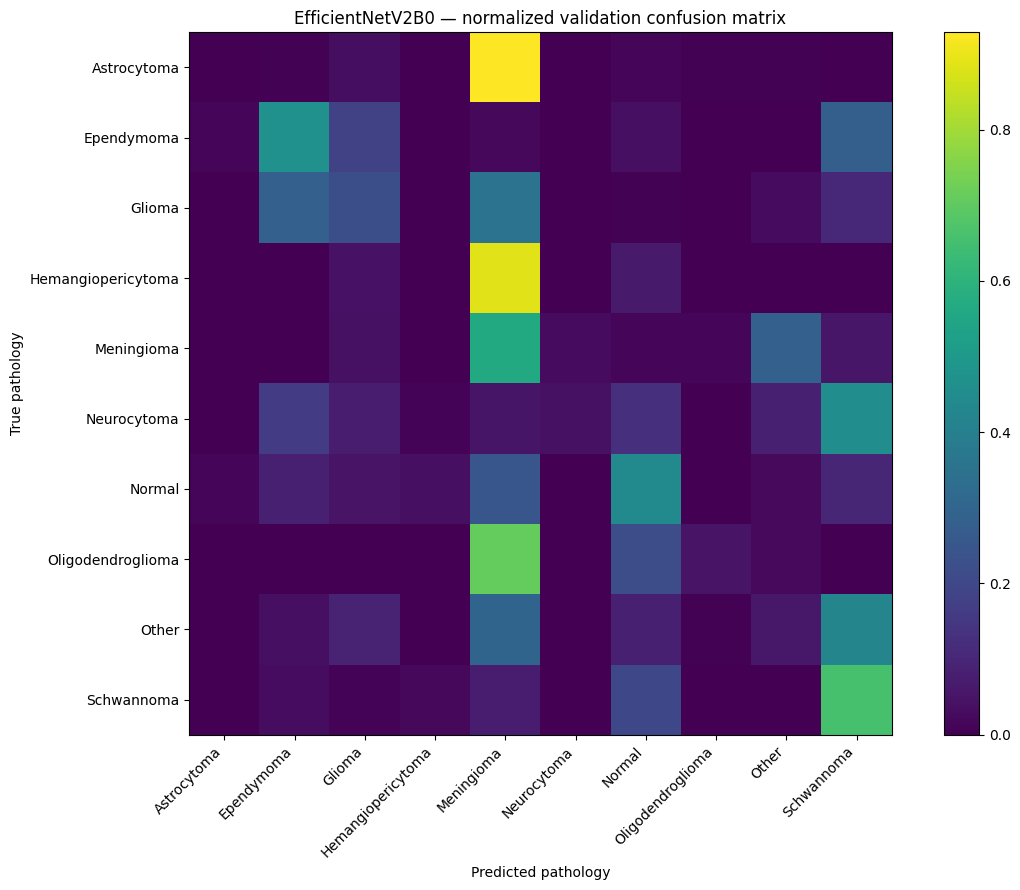

In [31]:
fig, ax = plt.subplots(
    figsize=(12, 9)
)

im = ax.imshow(
    cm_normalized.values
)

ax.set_xticks(
    range(len(CLASS_NAMES))
)

ax.set_yticks(
    range(len(CLASS_NAMES))
)

ax.set_xticklabels(
    CLASS_NAMES,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    CLASS_NAMES
)

ax.set_xlabel(
    "Predicted pathology"
)

ax.set_ylabel(
    "True pathology"
)

ax.set_title(
    "EfficientNetV2B0 — normalized validation confusion matrix"
)

fig.colorbar(
    im,
    ax=ax
)

plt.tight_layout()
plt.show()

## 14. Dominant predictions by true pathology

In [32]:
dominant_rows = []

for true_idx, pathology in enumerate(CLASS_NAMES):

    subset = val_results[
        val_results["y_true"] == true_idx
    ]

    prediction_counts = (
        subset["y_pred"]
        .value_counts()
    )

    dominant_idx = (
        prediction_counts.idxmax()
    )

    dominant_count = (
        prediction_counts.max()
    )

    dominant_rows.append(
        {
            "true_pathology": pathology,
            "n_images": len(subset),
            "most_predicted_as":
                idx_to_class[dominant_idx],
            "prediction_pct":
                100
                * dominant_count
                / len(subset),
            "class_accuracy":
                100
                * subset["correct"].mean()
        }
    )

dominant_predictions = pd.DataFrame(
    dominant_rows
)

dominant_predictions.round(1)

,true_pathology,n_images,most_predicted_as,prediction_pct,class_accuracy
0,Astrocytoma,168,Meningioma,92.9,0.0
1,Ependymoma,156,Ependymoma,46.8,46.8
2,Glioma,221,Meningioma,35.3,22.2
3,Hemangiopericytoma,89,Meningioma,88.8,0.0
4,Meningioma,311,Meningioma,56.3,56.3
5,Neurocytoma,97,Schwannoma,45.4,4.1
6,Normal,160,Normal,44.4,44.4
7,Oligodendroglioma,82,Meningioma,70.7,4.9
8,Other,230,Schwannoma,42.2,6.1
9,Schwannoma,185,Schwannoma,65.9,65.9


## 15. MRI modality diagnosis

In [33]:
modality_performance = (
    val_results
    .groupby("modality")
    .agg(
        n_images=("correct", "size"),
        n_correct=("correct", "sum"),
        accuracy=("correct", "mean")
    )
)

modality_performance

,n_images,n_correct,accuracy
modality,,,
T1,656,192,0.292683
T1C+,624,165,0.264423
T2,419,155,0.369928


In [34]:
pathology_modality_performance = (
    val_results
    .groupby(
        ["pathology", "modality"]
    )
    .agg(
        n_images=("correct", "size"),
        n_correct=("correct", "sum"),
        accuracy=("correct", "mean")
    )
    .reset_index()
)

pathology_modality_performance[
    "accuracy_pct"
] = (
    100
    * pathology_modality_performance[
        "accuracy"
    ]
)

pathology_modality_performance

,pathology,modality,n_images,n_correct,accuracy,accuracy_pct
0,Astrocytoma,T1,85,0,0.000000,0.000000
1,Astrocytoma,T1C+,49,0,0.000000,0.000000
2,Astrocytoma,T2,34,0,0.000000,0.000000
3,Ependymoma,T1,70,27,0.385714,38.571429
4,Ependymoma,T1C+,63,34,0.539683,53.968254
5,Ependymoma,T2,23,12,0.521739,52.173913
6,Glioma,T1,84,23,0.273810,27.380952
7,Glioma,T1C+,71,15,0.211268,21.126761
8,Glioma,T2,66,11,0.166667,16.666667
9,Hemangiopericytoma,T1,34,0,0.000000,0.000000


In [35]:
modality_pivot = (
    pathology_modality_performance
    .pivot(
        index="pathology",
        columns="modality",
        values="accuracy"
    )
)

modality_pivot.round(3)

modality,T1,T1C+,T2
pathology,,,
Astrocytoma,0.000,0.000,0.000
Ependymoma,0.386,0.540,0.522
Glioma,0.274,0.211,0.167
Hemangiopericytoma,0.000,0.000,0.000
Meningioma,0.491,0.552,0.694
Neurocytoma,0.000,0.032,0.095
Normal,0.392,NaN,0.524
Oligodendroglioma,0.000,0.138,0.000
Other,0.117,0.015,0.135


## 16. Framing / acquisition diagnosis

In [36]:
from PIL import Image
import numpy as np

def compute_black_pixel_ratio(image_path):
    image = Image.open(
        image_path
    ).convert("L")

    arr = np.asarray(image)

    return np.mean(
        arr <= 5
    )

In [37]:
diagnosis_df = pd.concat(
    [train_df, val_df],
    axis=0
).copy()

In [38]:
diagnosis_df["image_path"] = (
    PROJECT_ROOT
    / diagnosis_df[
        "resolved_relative_path"
    ]
)

diagnosis_df["image_path"] = (
    diagnosis_df["image_path"]
    .astype(str)
)

In [39]:
diagnosis_df[
    "black_pixel_ratio"
] = (
    diagnosis_df[
        "image_path"
    ]
    .apply(
        compute_black_pixel_ratio
    )
)

In [40]:
diagnosis_df[
    "black_pixel_ratio"
].describe()

,black_pixel_ratio
count,9627.000000
mean,0.363798
std,0.250827
min,0.000000
25%,0.094276
50%,0.428631
75%,0.574858
max,0.874287


In [41]:
diagnosis_df.groupby(
    "split"
)[
    "black_pixel_ratio"
].describe()

,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
train,7928.0,0.370960,0.249278,0.0,0.094841,0.439762,0.578026,0.874287
validation,1699.0,0.330379,0.255364,0.0,0.076174,0.315739,0.549732,0.795280


In [42]:
framing_by_pathology = (
    diagnosis_df
    .groupby(
        ["pathology", "split"]
    )["black_pixel_ratio"]
    .agg(
        n_images="size",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max"
    )
    .round(3)
)

framing_by_pathology

n_images   mean  median    std    min    max
pathology          split                                                   
Astrocytoma        train            782  0.365   0.454  0.257  0.000  0.779
                   validation       168  0.206   0.094  0.229  0.000  0.611
Ependymoma         train            725  0.497   0.533  0.240  0.000  0.813
                   validation       156  0.607   0.709  0.201  0.000  0.760
Glioma             train           1034  0.375   0.453  0.222  0.000  0.757
                   validation       221  0.434   0.509  0.243  0.076  0.770
Hemangiopericytoma train            428  0.314   0.432  0.243  0.000  0.705
                   validation        89  0.200   0.004  0.240  0.000  0.580
Meningioma         train           1449  0.408   0.470  0.263  0.000  0.874
                   validation       311  0.287   0.186  0.228  0.000  0.795
Neurocytoma        train            436  0.345   0.314  0.199  0.000  0.661
                   validation        97  0.514   0.537  0.151  0.000  0.731
Normal             train            750  0.260   0.376  0.246  0.000  0.745
                   validation       160  0.111   0.000  0.172  0.000  0.502
Oligodendroglioma  train            385  0.303   0.409  0.233  0.000  0.679
                   validation        82  0.384   0.472  0.243  0.000  0.704
Other              train           1073  0.386   0.480  0.235  0.000  0.806
                   validation       230  0.457   0.449  0.139  0.197  0.715
Schwannoma         train            866  0.352   0.307  0.249  0.000  0.700
                   validation       185  0.135   0.068  0.153  0.000  0.608

In [43]:
framing_shift = (
    diagnosis_df
    .groupby(
        ["pathology", "split"]
    )["black_pixel_ratio"]
    .median()
    .unstack()
)

framing_shift[
    "median_shift"
] = (
    framing_shift["validation"]
    - framing_shift["train"]
)

framing_shift[
    "abs_median_shift"
] = (
    framing_shift[
        "median_shift"
    ].abs()
)

framing_shift.sort_values(
    "abs_median_shift",
    ascending=False
).round(3)

split,train,validation,median_shift,abs_median_shift
pathology,,,,
Hemangiopericytoma,0.432,0.004,-0.427,0.427
Normal,0.376,0.000,-0.376,0.376
Astrocytoma,0.454,0.094,-0.360,0.360
Meningioma,0.470,0.186,-0.284,0.284
Schwannoma,0.307,0.068,-0.239,0.239
Neurocytoma,0.314,0.537,0.222,0.222
Ependymoma,0.533,0.709,0.177,0.177
Oligodendroglioma,0.409,0.472,0.063,0.063
Glioma,0.453,0.509,0.057,0.057


In [44]:
# Median framing reference learned from the training partition
train_framing_reference = (
    diagnosis_df[
        diagnosis_df["split"] == "train"
    ]
    .groupby("pathology")[
        "black_pixel_ratio"
    ]
    .median()
)

train_framing_reference

,black_pixel_ratio
pathology,
Astrocytoma,0.454044
Ependymoma,0.532528
Glioma,0.452660
Hemangiopericytoma,0.431873
Meningioma,0.469948
Neurocytoma,0.314472
Normal,0.376188
Oligodendroglioma,0.408768
Other,0.479637


In [47]:
for name in [
    "model",
    "val_dataset",
    "val_paths",
    "val_labels",
    "class_to_idx",
    "idx_to_class"
]:
    print(
        f"{name:15}",
        "✓ exists" if name in globals() else "✗ missing"
    )

model           ✓ exists
val_dataset     ✗ missing
val_paths       ✓ exists
val_labels      ✓ exists
class_to_idx    ✓ exists
idx_to_class    ✓ exists


In [48]:
import tensorflow as tf

BATCH_SIZE = 32
IMG_SIZE = (224, 224)

def load_val_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    )

    return image, label


val_dataset = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            val_paths,
            val_labels
        )
    )
    .map(
        load_val_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

In [49]:
images, labels = next(
    iter(val_dataset)
)

print("Images:", images.shape)
print("Labels:", labels.shape)
print(
    "Pixel range:",
    float(tf.reduce_min(images)),
    float(tf.reduce_max(images))
)
print(
    "Validation images:",
    len(val_paths)
)

Images: (32, 224, 224, 3)
Labels: (32,)
Pixel range: 0.0 255.0
Validation images: 1699


In [50]:
val_probabilities = model.predict(
    val_dataset,
    verbose=1
)

val_predictions = np.argmax(
    val_probabilities,
    axis=1
)

print(
    "Probabilities:",
    val_probabilities.shape
)

print(
    "Predictions:",
    val_predictions.shape
)

print(
    "True labels:",
    val_labels.shape
)

print(
    "Validation accuracy:",
    np.mean(
        val_predictions == val_labels
    )
)

54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step
Probabilities: (1699, 10)
Predictions: (1699,)
True labels: (1699,)
Validation accuracy: 0.3013537374926427


In [51]:
results_df = val_df[
    [
        "pathology",
        "modality",
        "split_group",
        "image_path"
    ]
].copy()

results_df["y_true"] = val_labels
results_df["y_pred"] = val_predictions

results_df["correct"] = (
    results_df["y_true"]
    == results_df["y_pred"]
)

print(results_df.shape)

results_df.head()

(1699, 7)


,pathology,modality,split_group,image_path,y_true,y_pred,correct
9601,Astrocytoma,T1C+,0,/content/brain-tumor-mri/data/raw/Astrocytoma ...,0,4,False
9602,Astrocytoma,T1C+,0,/content/brain-tumor-mri/data/raw/Astrocytoma ...,0,4,False
9603,Astrocytoma,T1C+,0,/content/brain-tumor-mri/data/raw/Astrocytoma ...,0,2,False
9604,Astrocytoma,T1,0,/content/brain-tumor-mri/data/raw/Astrocytoma ...,0,4,False
9605,Astrocytoma,T1,0,/content/brain-tumor-mri/data/raw/Astrocytoma ...,0,4,False


In [52]:
print(
    "Image-level validation accuracy:",
    results_df["correct"].mean()
)

Image-level validation accuracy: 0.3013537374926427


In [55]:
# Recover validation framing information from diagnosis_df

val_framing = (
    diagnosis_df[
        diagnosis_df["split"] == "validation"
    ][
        [
            "image_path",
            "black_pixel_ratio"
        ]
    ]
    .copy()
)

print("Validation framing rows:", len(val_framing))
print(
    "Missing black_pixel_ratio:",
    val_framing["black_pixel_ratio"].isna().sum()
)

val_framing.head()

Validation framing rows: 1699
Missing black_pixel_ratio: 0


,image_path,black_pixel_ratio
9601,/content/brain-tumor-mri/data/raw/Astrocytoma ...,0.224094
9602,/content/brain-tumor-mri/data/raw/Astrocytoma ...,0.223881
9603,/content/brain-tumor-mri/data/raw/Astrocytoma ...,0.222427
9604,/content/brain-tumor-mri/data/raw/Astrocytoma ...,0.565075
9605,/content/brain-tumor-mri/data/raw/Astrocytoma ...,0.566055


In [56]:
# Merge framing information with model predictions

results_framing = results_df.merge(
    val_framing,
    on="image_path",
    how="left",
    validate="one_to_one"
)

# Reference framing = median black-pixel ratio
# observed in training for each pathology
results_framing["train_framing_median"] = (
    results_framing["pathology"]
    .map(train_framing_reference)
)

# Absolute distance from the training reference
results_framing["framing_distance"] = (
    results_framing["black_pixel_ratio"]
    - results_framing["train_framing_median"]
).abs()

print("Shape:", results_framing.shape)

print(
    "Missing black_pixel_ratio:",
    results_framing["black_pixel_ratio"].isna().sum()
)

print(
    "Missing train reference:",
    results_framing["train_framing_median"].isna().sum()
)

results_framing[
    [
        "pathology",
        "black_pixel_ratio",
        "train_framing_median",
        "framing_distance",
        "correct"
    ]
].head()

Shape: (1699, 10)
Missing black_pixel_ratio: 0
Missing train reference: 0


,pathology,black_pixel_ratio,train_framing_median,framing_distance,correct
0,Astrocytoma,0.224094,0.454044,0.229950,False
1,Astrocytoma,0.223881,0.454044,0.230164,False
2,Astrocytoma,0.222427,0.454044,0.231617,False
3,Astrocytoma,0.565075,0.454044,0.111031,False
4,Astrocytoma,0.566055,0.454044,0.112011,False


In [57]:
framing_correctness = (
    results_framing
    .groupby("correct")["framing_distance"]
    .agg(
        n_images="size",
        mean="mean",
        median="median",
        std="std"
    )
    .round(4)
)

framing_correctness

,n_images,mean,median,std
correct,,,,
False,1187,0.2342,0.2314,0.1329
True,512,0.2118,0.1886,0.1248


In [58]:
framing_by_pathology_correctness = (
    results_framing
    .groupby(["pathology", "correct"])["framing_distance"]
    .agg(
        n_images="size",
        mean="mean",
        median="median"
    )
    .round(4)
)

framing_by_pathology_correctness

n_images    mean  median
pathology          correct                          
Astrocytoma        False         168  0.2837  0.3603
Ependymoma         False          83  0.1680  0.2193
                   True           73  0.1805  0.1823
Glioma             False         172  0.2469  0.2495
                   True           49  0.1815  0.1857
Hemangiopericytoma False          89  0.2852  0.4275
Meningioma         False         136  0.3189  0.3401
                   True          175  0.2157  0.1807
Neurocytoma        False          93  0.2442  0.2274
                   True            4  0.1379  0.1380
Normal             False          89  0.2818  0.3755
                   True           71  0.3110  0.3762
Oligodendroglioma  False          78  0.2140  0.2286
                   True            4  0.0617  0.0628
Other              False         216  0.1224  0.1003
                   True           14  0.0849  0.0511
Schwannoma         False          63  0.2258  0.3011
                   True          122  0.2014  0.2382

In [59]:
framing_comparison = (
    results_framing
    .groupby(["pathology", "correct"])["framing_distance"]
    .median()
    .unstack()
    .rename(
        columns={
            False: "incorrect_median_distance",
            True: "correct_median_distance"
        }
    )
)

framing_comparison["difference"] = (
    framing_comparison["incorrect_median_distance"]
    - framing_comparison["correct_median_distance"]
)

framing_comparison.sort_values(
    "difference",
    ascending=False
).round(4)

correct,incorrect_median_distance,correct_median_distance,difference
pathology,,,
Oligodendroglioma,0.2286,0.0628,0.1658
Meningioma,0.3401,0.1807,0.1594
Neurocytoma,0.2274,0.1380,0.0894
Glioma,0.2495,0.1857,0.0638
Schwannoma,0.3011,0.2382,0.0629
Other,0.1003,0.0511,0.0492
Ependymoma,0.2193,0.1823,0.0370
Normal,0.3755,0.3762,-0.0006
Astrocytoma,0.3603,NaN,NaN


In [60]:
results_framing["framing_distance_quartile"] = pd.qcut(
    results_framing["framing_distance"],
    q=4,
    labels=[
        "Q1 - closest",
        "Q2",
        "Q3",
        "Q4 - furthest"
    ]
)

framing_quartiles = (
    results_framing
    .groupby(
        "framing_distance_quartile",
        observed=True
    )
    .agg(
        n_images=("correct", "size"),
        accuracy=("correct", "mean"),
        median_distance=("framing_distance", "median")
    )
)

framing_quartiles["accuracy_pct"] = (
    framing_quartiles["accuracy"] * 100
)

framing_quartiles.round(4)

,n_images,accuracy,median_distance,accuracy_pct
framing_distance_quartile,,,,
Q1 - closest,425,0.2988,0.0643,29.8824
Q2,425,0.4282,0.1807,42.8235
Q3,424,0.2170,0.2663,21.6981
Q4 - furthest,425,0.2612,0.3765,26.1176


### Framing-shift findings

Substantial train-validation differences in black-pixel ratio were observed for several pathologies, indicating a measurable shift in image framing.

Incorrectly classified validation images were generally farther from their pathology-specific training framing reference than correctly classified images (median distance: 0.231 vs. 0.189). The same direction was observed in 7 of the 8 classes for which correct and incorrect predictions could be compared.

However, accuracy did not decrease monotonically with framing distance. Validation accuracy was 29.9%, 42.8%, 21.7%, and 26.1% across increasing framing-distance quartiles (Q1–Q4), respectively.

Therefore, framing differences are associated with model errors but do not provide a sufficient standalone explanation for the generalization gap. Other sources of between-case heterogeneity should be investigated.

## 17. Case-level heterogeneity

In [61]:
group_performance = (
    results_df
    .groupby(
        ["split_group", "pathology"]
    )
    .agg(
        n_images=("correct", "size"),
        n_correct=("correct", "sum"),
        accuracy=("correct", "mean")
    )
    .reset_index()
)

group_performance["accuracy_pct"] = (
    group_performance["accuracy"] * 100
)

print("Validation groups:", len(group_performance))

print(
    "\nGroup-level accuracy summary:"
)

print(
    group_performance["accuracy"]
    .describe()
    .round(3)
)

group_performance.sort_values(
    "accuracy"
).head(15)

Validation groups: 55

Group-level accuracy summary:
count    55.000
mean      0.275
std       0.330
min       0.000
25%       0.000
50%       0.154
75%       0.543
max       1.000
Name: accuracy, dtype: float64


,split_group,pathology,n_images,n_correct,accuracy,accuracy_pct
0,0,Astrocytoma,11,0,0.0,0.0
1,2,Astrocytoma,6,0,0.0,0.0
2,3,Astrocytoma,53,0,0.0,0.0
3,4,Astrocytoma,47,0,0.0,0.0
4,5,Astrocytoma,3,0,0.0,0.0
5,6,Astrocytoma,4,0,0.0,0.0
6,7,Astrocytoma,29,0,0.0,0.0
7,8,Astrocytoma,3,0,0.0,0.0
8,10,Astrocytoma,12,0,0.0,0.0
12,81,Glioma,47,0,0.0,0.0


In [62]:
group_accuracy_distribution = pd.cut(
    group_performance["accuracy"],
    bins=[-0.001, 0, 0.25, 0.50, 0.75, 1.0],
    labels=[
        "0%",
        ">0–25%",
        ">25–50%",
        ">50–75%",
        ">75–100%"
    ]
).value_counts().sort_index()

group_accuracy_distribution

,count
accuracy,
0%,24
>0–25%,10
>25–50%,7
>50–75%,8
>75–100%,6


In [63]:
print(
    "Groups with 0% accuracy:",
    (group_performance["accuracy"] == 0).sum(),
    "/",
    len(group_performance)
)

print(
    "Groups with 100% accuracy:",
    (group_performance["accuracy"] == 1).sum(),
    "/",
    len(group_performance)
)

print(
    "Median group accuracy:",
    group_performance["accuracy"].median()
)

print(
    "Image-weighted accuracy:",
    results_df["correct"].mean()
)

print(
    "Macro group accuracy:",
    group_performance["accuracy"].mean()
)

Groups with 0% accuracy: 24 / 55
Groups with 100% accuracy: 3 / 55
Median group accuracy: 0.15384615384615385
Image-weighted accuracy: 0.3013537374926427
Macro group accuracy: 0.2748687640590233


In [64]:
case_variability_by_pathology = (
    group_performance
    .groupby("pathology")
    .agg(
        n_groups=("split_group", "nunique"),
        mean_group_accuracy=("accuracy", "mean"),
        median_group_accuracy=("accuracy", "median"),
        std_group_accuracy=("accuracy", "std"),
        min_group_accuracy=("accuracy", "min"),
        max_group_accuracy=("accuracy", "max"),
        zero_accuracy_groups=("accuracy", lambda x: (x == 0).sum())
    )
)

case_variability_by_pathology["zero_group_pct"] = (
    100
    * case_variability_by_pathology["zero_accuracy_groups"]
    / case_variability_by_pathology["n_groups"]
)

case_variability_by_pathology.round(3)

,n_groups,mean_group_accuracy,median_group_accuracy,std_group_accuracy,min_group_accuracy,max_group_accuracy,zero_accuracy_groups,zero_group_pct
pathology,,,,,,,,
Astrocytoma,9,0.000,0.000,0.000,0.000,0.000,9,100.000
Ependymoma,3,0.409,0.385,0.182,0.240,0.602,0,0.000
Glioma,8,0.289,0.283,0.237,0.000,0.667,2,25.000
Hemangiopericytoma,2,0.000,0.000,0.000,0.000,0.000,2,100.000
Meningioma,10,0.662,0.755,0.358,0.000,1.000,1,10.000
Neurocytoma,2,0.103,0.103,0.112,0.023,0.182,0,0.000
Normal,2,0.377,0.377,0.302,0.164,0.590,0,0.000
Oligodendroglioma,4,0.038,0.000,0.077,0.000,0.154,3,75.000
Other,9,0.042,0.000,0.117,0.000,0.353,7,77.778


In [65]:
group_performance[
    [
        "pathology",
        "split_group",
        "n_images",
        "n_correct",
        "accuracy"
    ]
].sort_values(
    ["pathology", "accuracy"]
).round(3)

,pathology,split_group,n_images,n_correct,accuracy
0,Astrocytoma,0,11,0,0.000
1,Astrocytoma,2,6,0,0.000
2,Astrocytoma,3,53,0,0.000
3,Astrocytoma,4,47,0,0.000
4,Astrocytoma,5,3,0,0.000
5,Astrocytoma,6,4,0,0.000
6,Astrocytoma,7,29,0,0.000
7,Astrocytoma,8,3,0,0.000
8,Astrocytoma,10,12,0,0.000
10,Ependymoma,60,50,12,0.240


In [66]:
group_framing = (
    results_framing
    .groupby(["pathology", "split_group"])
    .agg(
        n_images=("correct", "size"),
        accuracy=("correct", "mean"),
        median_black_ratio=("black_pixel_ratio", "median"),
        median_framing_distance=("framing_distance", "median")
    )
    .reset_index()
)

group_framing["accuracy_pct"] = 100 * group_framing["accuracy"]

group_framing.sort_values(
    ["pathology", "accuracy"]
).round(3)

,pathology,split_group,n_images,accuracy,median_black_ratio,median_framing_distance,accuracy_pct
0,Astrocytoma,0,11,0.000,0.434,0.112,0.000
1,Astrocytoma,2,6,0.000,0.310,0.144,0.000
2,Astrocytoma,3,53,0.000,0.000,0.454,0.000
3,Astrocytoma,4,47,0.000,0.005,0.450,0.000
4,Astrocytoma,5,3,0.000,0.500,0.081,0.000
5,Astrocytoma,6,4,0.000,0.320,0.134,0.000
6,Astrocytoma,7,29,0.000,0.094,0.360,0.000
7,Astrocytoma,8,3,0.000,0.526,0.072,0.000
8,Astrocytoma,10,12,0.000,0.505,0.051,0.000
10,Ependymoma,60,50,0.240,0.498,0.034,24.000


In [67]:
from scipy.stats import spearmanr

rho, p_value = spearmanr(
    group_framing["median_framing_distance"],
    group_framing["accuracy"]
)

print(f"Spearman rho: {rho:.3f}")
print(f"p-value: {p_value:.4f}")

Spearman rho: -0.091
p-value: 0.5088


In [68]:
rows = []

for pathology, df in group_framing.groupby("pathology"):
    if len(df) >= 4:
        rho, p = spearmanr(
            df["median_framing_distance"],
            df["accuracy"]
        )

        rows.append({
            "pathology": pathology,
            "n_groups": len(df),
            "spearman_rho": rho,
            "p_value": p
        })

framing_group_correlations = (
    pd.DataFrame(rows)
    .sort_values("spearman_rho")
)

framing_group_correlations.round(3)

/tmp/ipykernel_2817/2193515345.py:5: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(


,pathology,n_groups,spearman_rho,p_value
3,Oligodendroglioma,4,-0.775,0.225
2,Meningioma,10,-0.767,0.010
1,Glioma,8,-0.755,0.031
5,Schwannoma,6,-0.638,0.173
4,Other,9,-0.183,0.638
0,Astrocytoma,9,NaN,NaN


Framing differences do not explain validation performance globally. However, within some pathologies—particularly Meningioma and Glioma—case groups that differ more strongly from the training framing distribution tend to generalize substantially worse. Framing heterogeneity therefore appears to be a pathology-dependent contributor to case-level generalization failure rather than its sole cause.

## 18. Targeted inspection of case-level domain heterogeneity

The previous analyses revealed substantial performance variation between
independent case groups belonging to the same pathology.

Framing distance was associated with group-level accuracy for some
pathologies, particularly Meningioma and Glioma, but did not explain
validation performance globally.

We therefore visually inspect high- and low-performing case groups within
the same pathology to determine whether additional acquisition, contrast,
orientation, framing, or image-domain differences are apparent.

Meningioma is examined first because its validation groups span the full
range of performance, from 0% to 100% accuracy.

In [69]:
meningioma_groups = (
    group_performance[
        group_performance["pathology"] == "Meningioma"
    ]
    .sort_values("accuracy")
    [
        [
            "split_group",
            "n_images",
            "n_correct",
            "accuracy"
        ]
    ]
    .copy()
)

meningioma_groups["accuracy_pct"] = (
    100 * meningioma_groups["accuracy"]
)

meningioma_groups.round(3)

,split_group,n_images,n_correct,accuracy,accuracy_pct
26,148,8,0,0.000,0.000
31,156,99,16,0.162,16.162
29,153,37,17,0.459,45.946
27,150,29,17,0.586,58.621
24,146,27,20,0.741,74.074
28,151,13,10,0.769,76.923
30,154,30,27,0.900,90.000
25,147,23,23,1.000,100.000
23,143,27,27,1.000,100.000
22,142,18,18,1.000,100.000


In [71]:
import matplotlib.pyplot as plt
from PIL import Image

def inspect_case_groups(
    df,
    pathology,
    group_ids,
    n_images_per_group=4
):
    subset = (
        df[
            (df["pathology"] == pathology)
            & (df["split_group"].isin(group_ids))
        ]
        .copy()
    )

    for group_id in group_ids:

        group_df = subset[
            subset["split_group"] == group_id
        ].copy()

        if group_df.empty:
            print(f"No images found for group {group_id}")
            continue

        group_accuracy = group_df["correct"].mean()

        sample = group_df.sample(
            n=min(n_images_per_group, len(group_df)),
            random_state=42
        )

        fig, axes = plt.subplots(
            1,
            len(sample),
            figsize=(4 * len(sample), 4)
        )

        if len(sample) == 1:
            axes = [axes]

        for ax, (_, row) in zip(axes, sample.iterrows()):

            image = Image.open(row["image_path"]).convert("RGB")

            ax.imshow(image)
            ax.axis("off")

            true_label = row["pathology"]
            predicted_label = idx_to_class[row["y_pred"]]

            ax.set_title(
                f"{row['modality']}\n"
                f"Pred: {predicted_label}\n"
                f"Black ratio: {row['black_pixel_ratio']:.2f}"
            )

        fig.suptitle(
            f"{pathology} — group {group_id} — "
            f"accuracy: {group_accuracy:.1%}",
            fontsize=14
        )

        plt.tight_layout()
        plt.show()

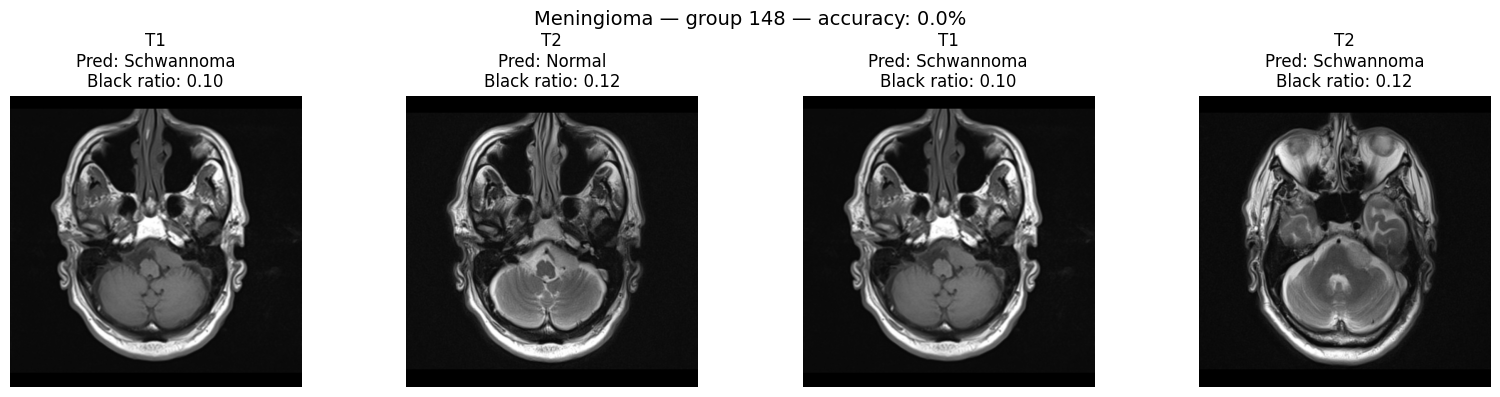

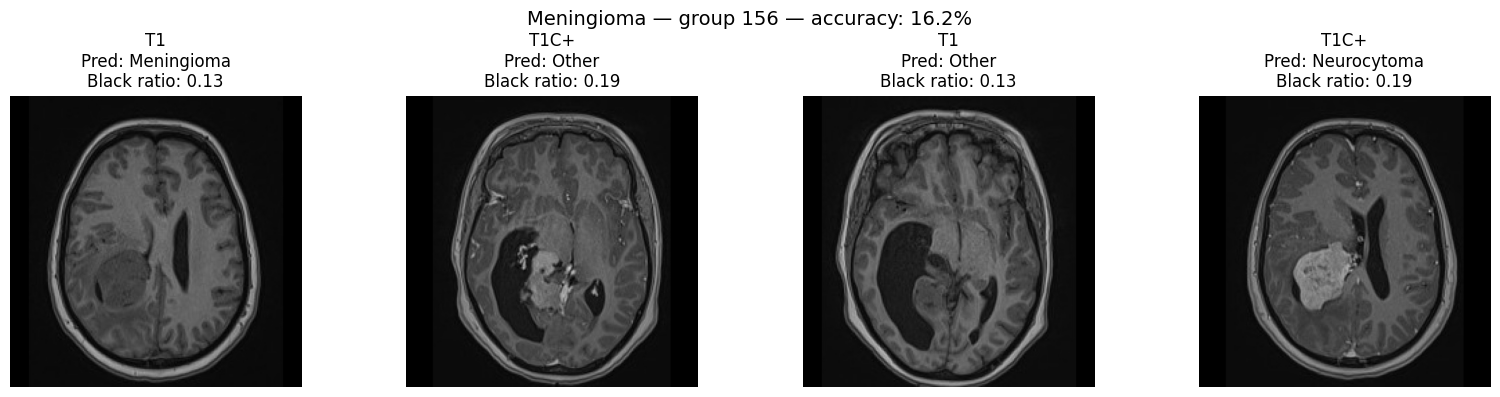

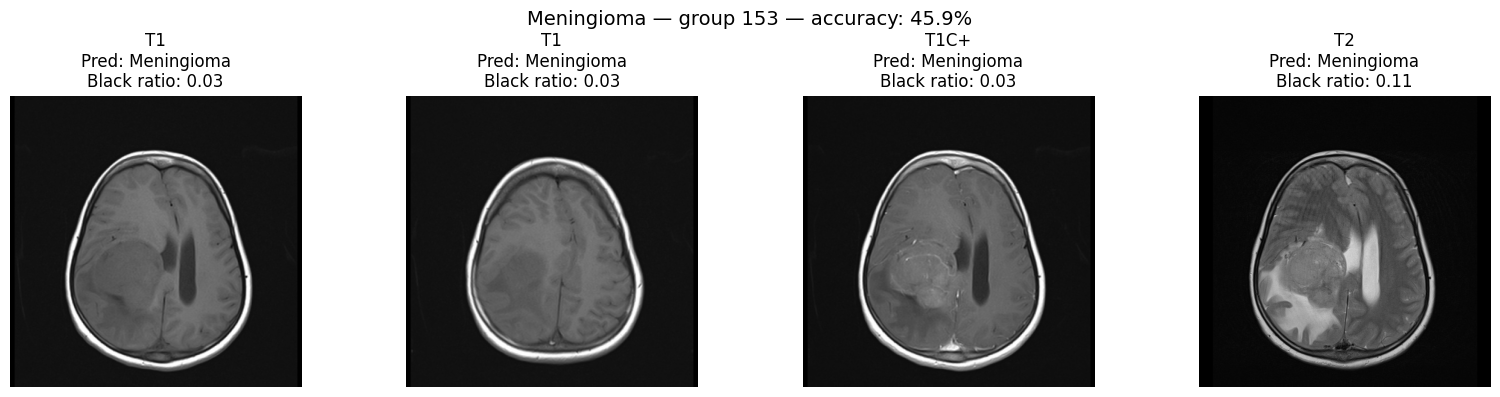

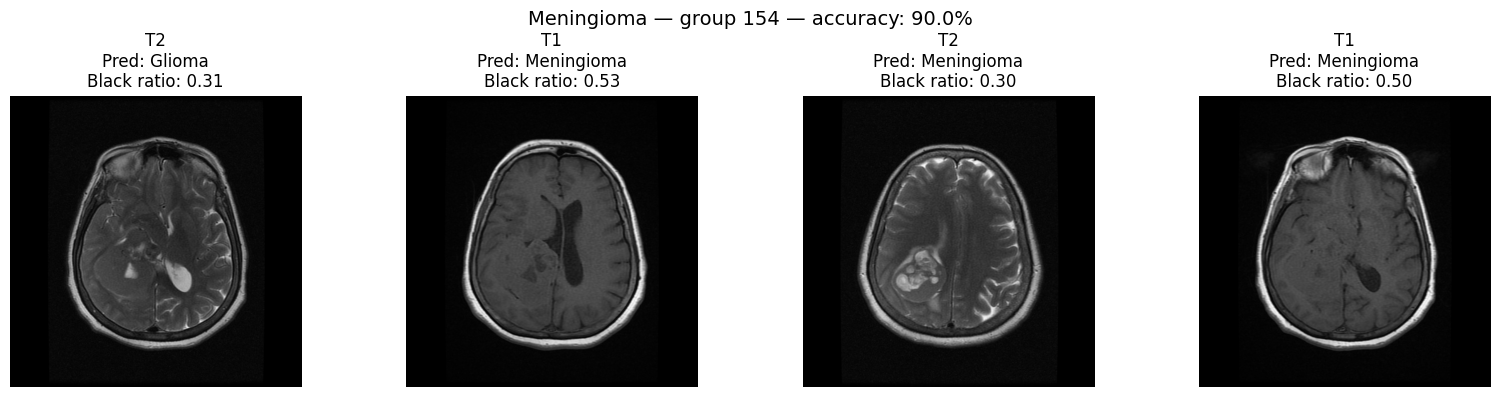

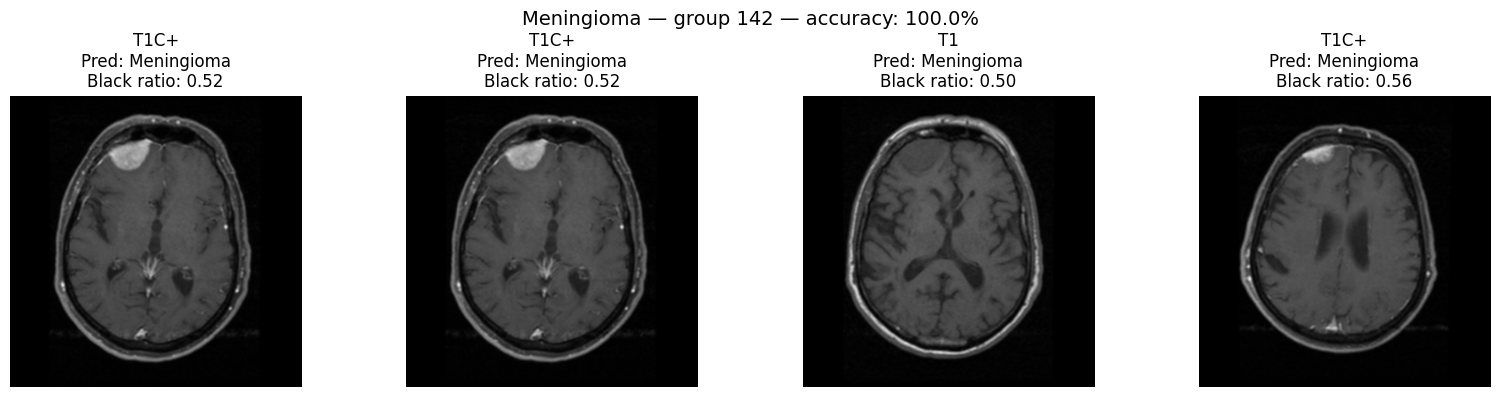

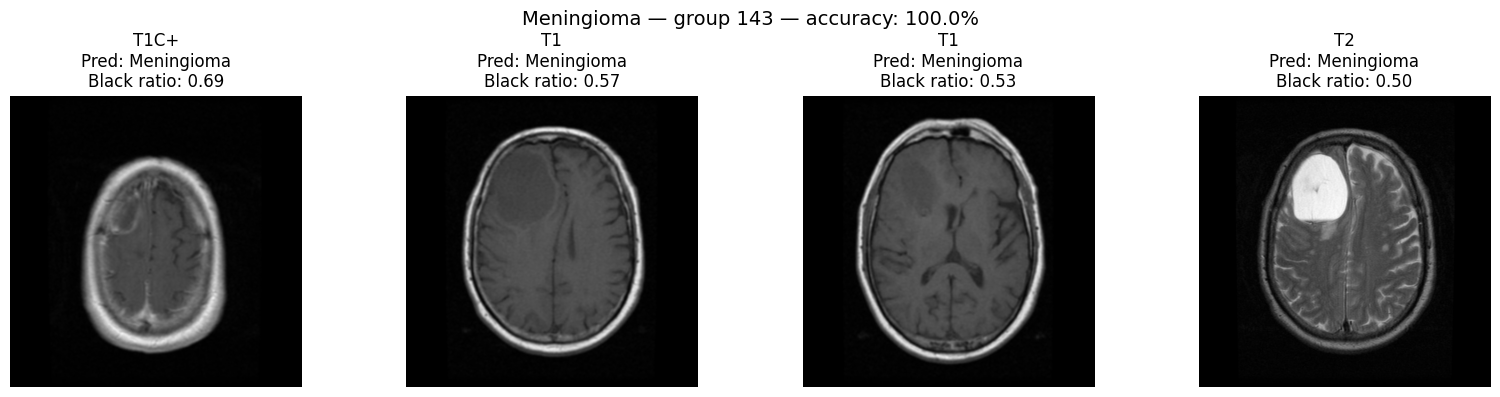

In [72]:
meningioma_groups_to_inspect = [
    148, 156, 153,   # lower-performing groups
    154, 142, 143    # higher-performing groups
]

inspect_case_groups(
    results_framing,
    pathology="Meningioma",
    group_ids=meningioma_groups_to_inspect,
    n_images_per_group=4
)

### 18.1. Meningioma

Meningioma exhibits substantial case-level heterogeneity, with validation
group accuracy ranging from 0% to 100%.

Visual inspection suggests marked differences in image framing and
acquisition appearance between several low- and high-performing groups.
In particular, some poorly performing groups contain tightly framed
images with substantially less background, whereas several highly
performing groups more closely resemble the typical training framing.

However, framing alone does not determine performance. Some groups with
limited background remain partially well classified, indicating that
additional case-level visual or acquisition characteristics are likely
involved.

In [73]:
glioma_groups = (
    group_performance[
        group_performance["pathology"] == "Glioma"
    ]
    .sort_values("accuracy")
    [
        [
            "split_group",
            "n_images",
            "n_correct",
            "accuracy"
        ]
    ]
    .copy()
)

glioma_groups["accuracy_pct"] = (
    100 * glioma_groups["accuracy"]
)

glioma_groups.round(3)

,split_group,n_images,n_correct,accuracy,accuracy_pct
12,81,47,0,0.000,0.000
18,90,39,0,0.000,0.000
15,86,29,5,0.172,17.241
17,88,15,3,0.200,20.000
13,82,30,11,0.367,36.667
19,91,19,8,0.421,42.105
16,87,33,16,0.485,48.485
14,85,9,6,0.667,66.667


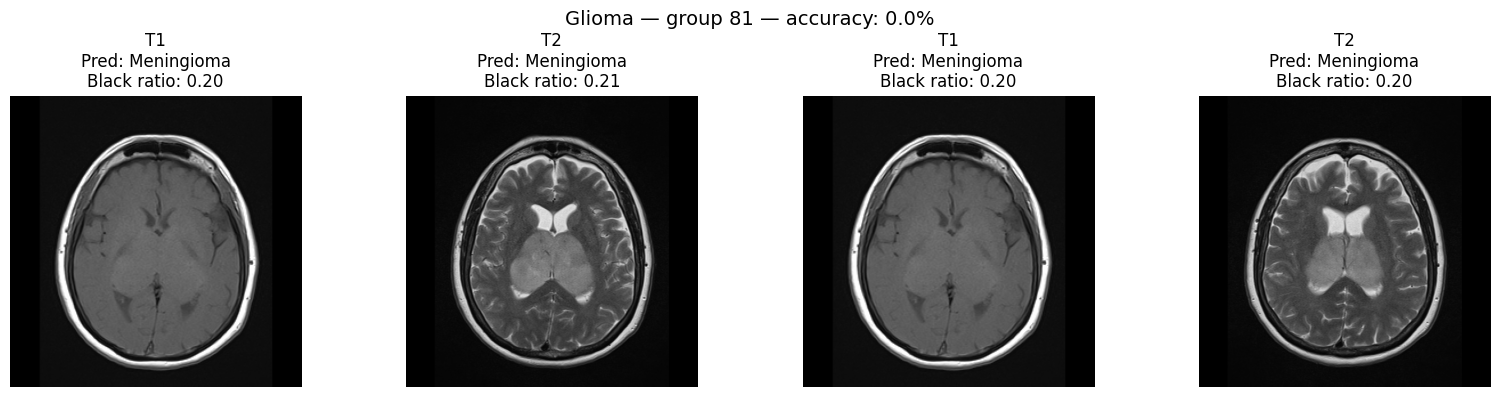

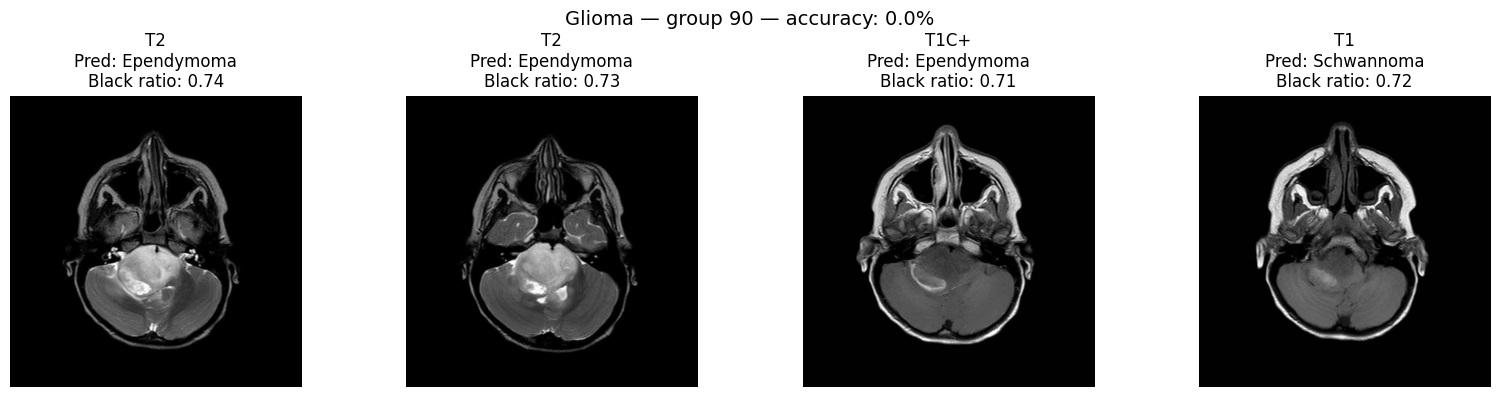

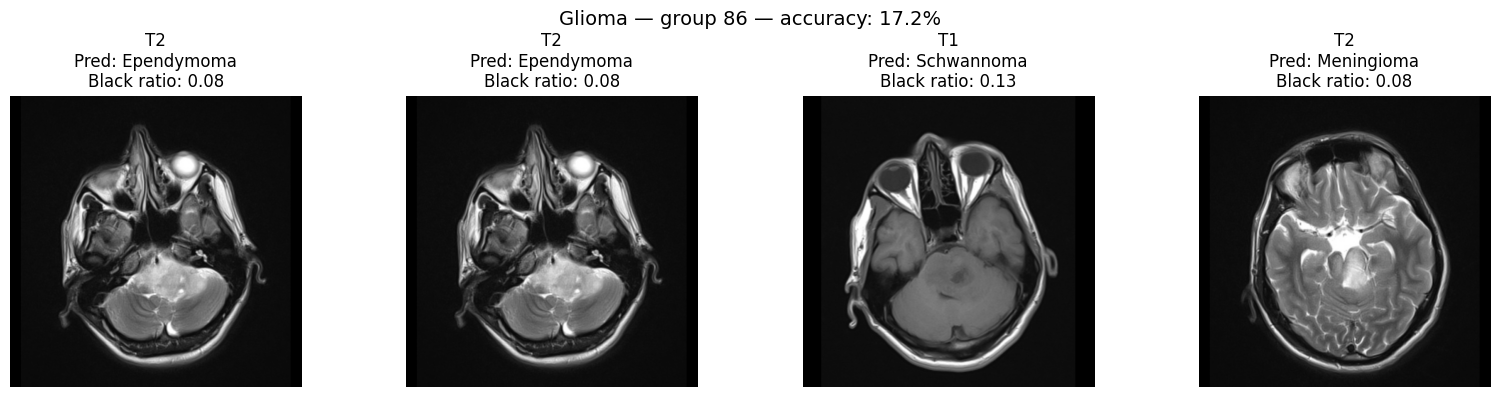

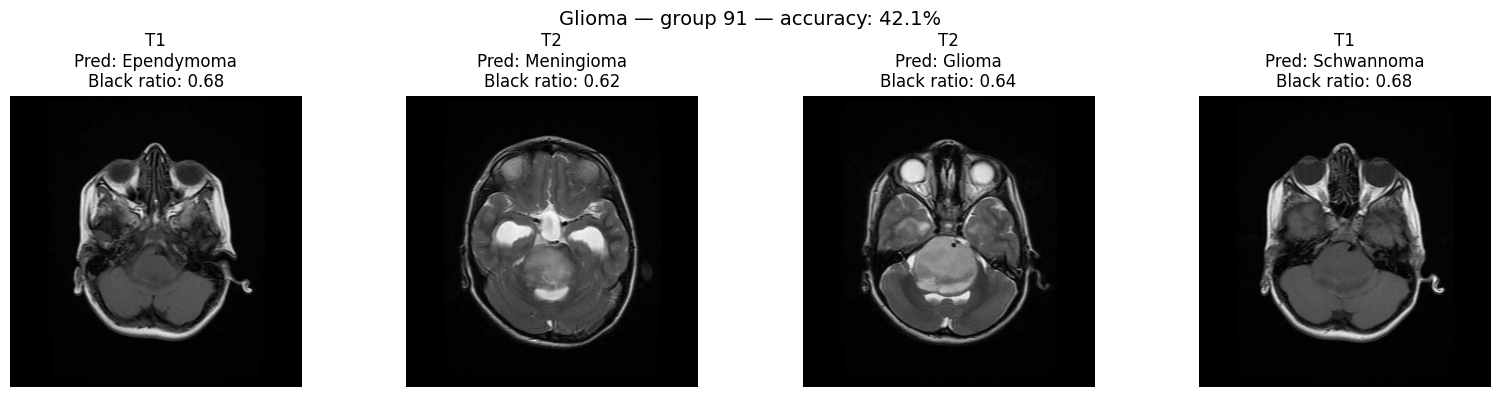

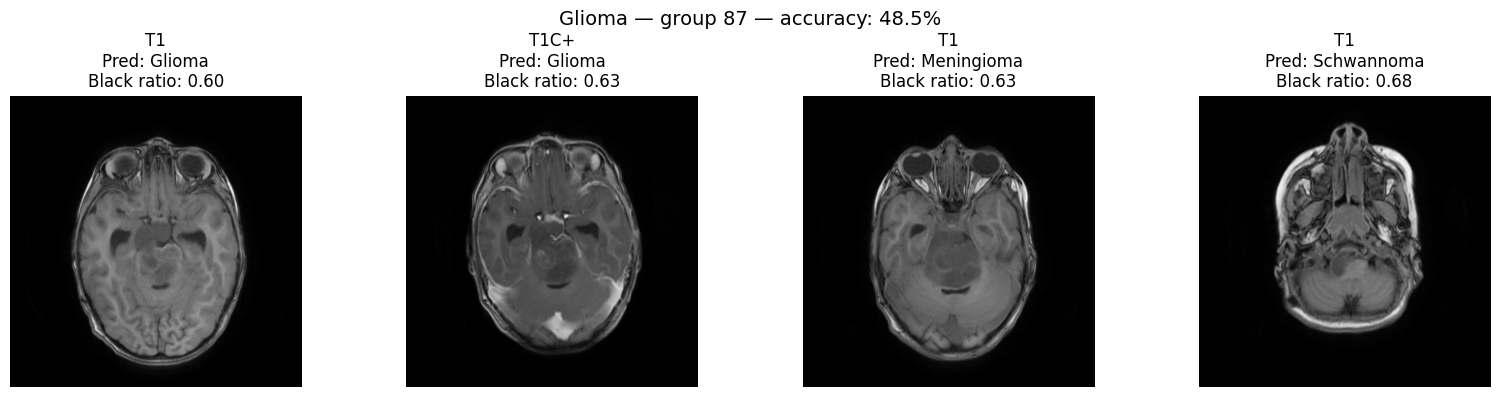

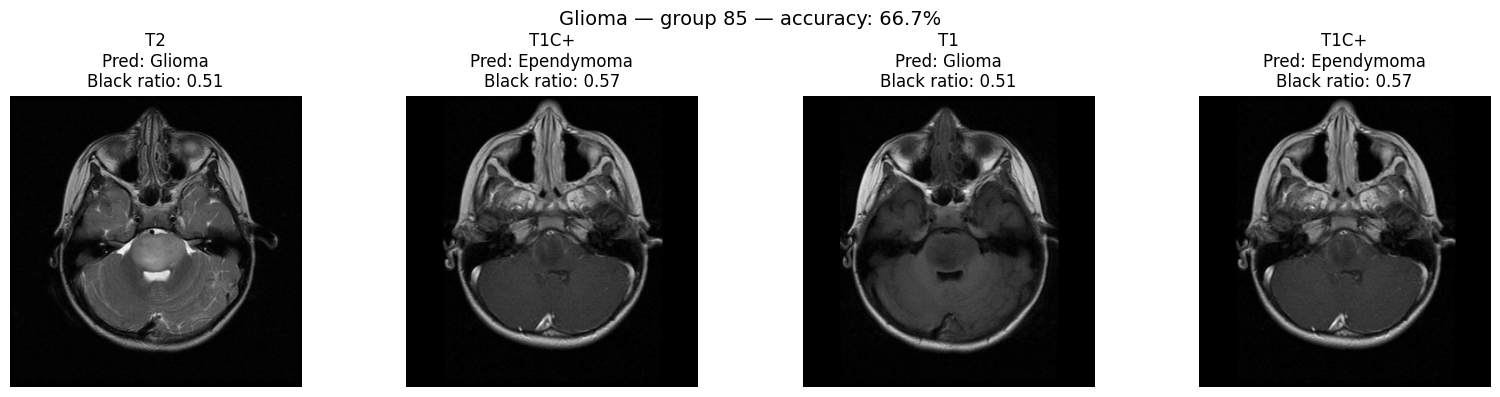

In [74]:
glioma_groups_to_inspect = [
    81, 90, 86,   # lower-performing groups
    91, 87, 85    # higher-performing groups
]

inspect_case_groups(
    results_framing,
    pathology="Glioma",
    group_ids=glioma_groups_to_inspect,
    n_images_per_group=4
)

In [75]:
# Check available anatomical-location annotations
location_diagnosis = (
    diagnosis_df
    .groupby(["split", "pathology"])["location"]
    .agg(
        n_images="size",
        n_missing=lambda x: x.isna().sum(),
        n_unique=lambda x: x.astype(str).nunique()
    )
)

location_diagnosis

n_images  n_missing  n_unique
split      pathology                                        
train      Astrocytoma              782          0        18
           Ependymoma               725          0        13
           Glioma                  1034          0        15
           Hemangiopericytoma       428          0         7
           Meningioma              1449          0        30
           Neurocytoma              436          0         4
           Normal                   750          0         4
           Oligodendroglioma        385          0         7
           Other                   1073          0        22
           Schwannoma               866          0        17
validation Astrocytoma              168          0         6
           Ependymoma               156          0         3
           Glioma                   221          0         5
           Hemangiopericytoma        89          0         2
           Meningioma               311          0        10
           Neurocytoma               97          0         2
           Normal                   160          0         1
           Oligodendroglioma         82          0         4
           Other                    230          0         7
           Schwannoma               185          0         6

In [76]:
diagnosis_df[
    ["pathology", "split_group", "split", "location"]
].sample(20, random_state=42)

,pathology,split_group,split,location
7054,Normal,228,train,[]
8332,Other,301,train,"['parietal', 'temporal']"
9172,Schwannoma,336,train,['ventricle']
4818,Meningioma,167,train,[]
8686,Other,315,train,['occipital']
2594,Ependymoma,64,train,['supratentorial']
10368,Meningioma,151,validation,"['temporal', 'ventricle']"
4391,Hemangiopericytoma,137,train,"['frontal', 'ventricle']"
6688,Normal,222,train,"['ventricle', 'brainstem']"
4980,Meningioma,169,train,"['frontal', 'ventricle']"


In [77]:
diagnosis_df["location"].value_counts(dropna=False).head(30)

,count
location,
[],1559
['ventricle'],1196
['frontal'],809
"['ventricle', 'brainstem']",552
"['frontal', 'ventricle']",435
"['temporal', 'ventricle']",264
['falx'],226
"['trigeminal', 'cerebellopontine angle']",226
"['posterior fossa', 'ventricle']",222


In [78]:
import ast
import numpy as np
import pandas as pd


def parse_location(x):
    """
    Convert location into a normalized set of anatomical labels.
    [] is treated as missing/unannotated.
    """
    if isinstance(x, list):
        values = x
    elif pd.isna(x):
        values = []
    else:
        try:
            values = ast.literal_eval(str(x))
        except (ValueError, SyntaxError):
            values = [str(x)]

    return {
        str(v).strip().lower()
        for v in values
        if str(v).strip()
    }


# ---------------------------------------------------------
# 1. Normalize location annotations
# ---------------------------------------------------------

diagnosis_df = diagnosis_df.copy()

diagnosis_df["location_set"] = (
    diagnosis_df["location"]
    .apply(parse_location)
)


# ---------------------------------------------------------
# 2. Anatomical vocabulary seen during training
#    for each pathology
# ---------------------------------------------------------

train_location_vocab = (
    diagnosis_df[
        diagnosis_df["split"] == "train"
    ]
    .groupby("pathology")["location_set"]
    .apply(
        lambda sets:
        set().union(*sets)
        if len(sets) > 0
        else set()
    )
    .to_dict()
)

print("Train anatomical vocabulary by pathology:")
for pathology, vocab in train_location_vocab.items():
    print(pathology, ":", sorted(vocab))


# ---------------------------------------------------------
# 3. Validation groups
# ---------------------------------------------------------

val_location_groups = (
    diagnosis_df[
        diagnosis_df["split"] == "validation"
    ]
    .groupby(
        ["pathology", "split_group"]
    )
    .agg(
        n_images=("location_set", "size"),
        location_sets=(
            "location_set",
            lambda x: list(x)
        )
    )
    .reset_index()
)


# Union of locations appearing in each validation group
val_location_groups["group_locations"] = (
    val_location_groups["location_sets"]
    .apply(
        lambda sets:
        set().union(*sets)
        if len(sets) > 0
        else set()
    )
)


# ---------------------------------------------------------
# 4. Compare validation locations with train vocabulary
# ---------------------------------------------------------

def location_coverage(row):

    val_locations = row["group_locations"]

    train_locations = train_location_vocab.get(
        row["pathology"],
        set()
    )

    # No anatomical annotation
    if len(val_locations) == 0:
        return pd.Series({
            "n_locations": 0,
            "n_seen_in_train": np.nan,
            "coverage": np.nan,
            "unseen_locations": []
        })

    seen = val_locations & train_locations
    unseen = val_locations - train_locations

    return pd.Series({
        "n_locations": len(val_locations),
        "n_seen_in_train": len(seen),
        "coverage": len(seen) / len(val_locations),
        "unseen_locations": sorted(unseen)
    })


coverage_info = (
    val_location_groups
    .apply(
        location_coverage,
        axis=1
    )
)

val_location_groups = pd.concat(
    [
        val_location_groups,
        coverage_info
    ],
    axis=1
)


# ---------------------------------------------------------
# 5. Add model performance
# ---------------------------------------------------------

location_group_performance = (
    group_performance[
        [
            "pathology",
            "split_group",
            "accuracy"
        ]
    ]
    .merge(
        val_location_groups,
        on=[
            "pathology",
            "split_group"
        ],
        how="left"
    )
)

location_group_performance["accuracy_pct"] = (
    100 *
    location_group_performance["accuracy"]
)


location_group_performance[
    [
        "pathology",
        "split_group",
        "n_images",
        "accuracy_pct",
        "group_locations",
        "coverage",
        "unseen_locations"
    ]
].sort_values(
    ["pathology", "accuracy_pct"]
).round(3)

Train anatomical vocabulary by pathology:
Astrocytoma : ['basal ganglia', 'brainstem', 'centrum semiovale', 'cerebellopontine angle', 'frontal', 'parietal', 'pineal', 'posterior fossa', 'suprasellar', 'supratentorial', 'temporal', 'ventricle']
Ependymoma : ['basal ganglia', 'brainstem', 'frontal', 'intraventricular', 'posterior fossa', 'supratentorial', 'temporal', 'tentorial', 'ventricle']
Glioma : ['basal ganglia', 'brainstem', 'clivus', 'frontal', 'posterior fossa', 'suprasellar', 'supratentorial', 'temporal', 'ventricle']
Hemangiopericytoma : ['falx', 'frontal', 'olfactory groove', 'pineal', 'temporal', 'ventricle']
Meningioma : ['anterior cranial fossa', 'brainstem', 'cavernous sinus', 'cerebellopontine angle', 'corona radiata', 'falx', 'frontal', 'infratentorial', 'interhemispheric', 'occipital', 'parafalcine', 'parietal', 'petroclival', 'petrous ridge', 'pineal', 'planum sphenoidale', 'posterior fossa', 'suprasellar', 'supratentorial', 'temporal', 'tentorial', 'ventricle']
Neuro

,pathology,split_group,n_images,accuracy_pct,group_locations,coverage,unseen_locations
0,Astrocytoma,0,11,0.000,{},NaN,[]
1,Astrocytoma,2,6,0.000,{},NaN,[]
2,Astrocytoma,3,53,0.000,"{ventricle, parietal}",1.0,[]
3,Astrocytoma,4,47,0.000,"{frontal, falx}",0.5,[falx]
4,Astrocytoma,5,3,0.000,{},NaN,[]
5,Astrocytoma,6,4,0.000,{frontal},1.0,[]
6,Astrocytoma,7,29,0.000,"{frontal, temporal}",1.0,[]
7,Astrocytoma,8,3,0.000,"{frontal, ventricle}",1.0,[]
8,Astrocytoma,10,12,0.000,"{frontal, temporal}",1.0,[]
10,Ependymoma,60,50,24.000,"{ventricle, posterior fossa}",1.0,[]


Anatomical location coverage does not explain the generalization failure globally. Most poorly performing validation groups use anatomical locations already represented in training. Some isolated unseen locations exist, but poor performance also occurs extensively among fully covered groups.

In [79]:
# ---------------------------------------------------------
# Exact anatomical configuration frequency in training
# ---------------------------------------------------------

def canonical_location(location_set):
    if not location_set:
        return "UNANNOTATED"
    return " | ".join(sorted(location_set))


diagnosis_df["location_signature"] = (
    diagnosis_df["location_set"]
    .apply(canonical_location)
)


# Number of TRAIN images for each exact
# pathology × anatomical configuration
train_location_frequency = (
    diagnosis_df[
        diagnosis_df["split"] == "train"
    ]
    .groupby(
        ["pathology", "location_signature"]
    )
    .size()
    .rename("train_location_n")
    .reset_index()
)


# Location signature for each validation group
val_group_locations = (
    diagnosis_df[
        diagnosis_df["split"] == "validation"
    ]
    .groupby(
        ["pathology", "split_group"]
    )
    .agg(
        n_images=("location_signature", "size"),
        location_signature=(
            "location_signature",
            lambda x: x.mode().iloc[0]
        ),
        n_location_signatures=(
            "location_signature",
            "nunique"
        )
    )
    .reset_index()
)


location_frequency_performance = (
    group_performance[
        [
            "pathology",
            "split_group",
            "accuracy"
        ]
    ]
    .merge(
        val_group_locations,
        on=["pathology", "split_group"],
        how="left"
    )
    .merge(
        train_location_frequency,
        on=["pathology", "location_signature"],
        how="left"
    )
)

location_frequency_performance["train_location_n"] = (
    location_frequency_performance["train_location_n"]
    .fillna(0)
    .astype(int)
)

location_frequency_performance["accuracy_pct"] = (
    100 * location_frequency_performance["accuracy"]
)


location_frequency_performance[
    [
        "pathology",
        "split_group",
        "n_images",
        "accuracy_pct",
        "location_signature",
        "n_location_signatures",
        "train_location_n"
    ]
].sort_values(
    ["pathology", "accuracy_pct"]
).round(3)

,pathology,split_group,n_images,accuracy_pct,location_signature,n_location_signatures,train_location_n
0,Astrocytoma,0,11,0.000,UNANNOTATED,1,129
1,Astrocytoma,2,6,0.000,UNANNOTATED,1,129
2,Astrocytoma,3,53,0.000,parietal | ventricle,1,42
3,Astrocytoma,4,47,0.000,falx | frontal,1,0
4,Astrocytoma,5,3,0.000,UNANNOTATED,1,129
5,Astrocytoma,6,4,0.000,frontal,1,98
6,Astrocytoma,7,29,0.000,frontal | temporal,1,0
7,Astrocytoma,8,3,0.000,frontal | ventricle,1,14
8,Astrocytoma,10,12,0.000,frontal | temporal,1,0
10,Ependymoma,60,50,24.000,posterior fossa | ventricle,1,24


In [80]:
from scipy.stats import spearmanr

annotated = location_frequency_performance[
    location_frequency_performance["location_signature"]
    != "UNANNOTATED"
].copy()

rho, p = spearmanr(
    annotated["train_location_n"],
    annotated["accuracy"]
)

print(f"Spearman rho: {rho:.3f}")
print(f"p-value: {p:.4f}")

annotated[
    [
        "pathology",
        "split_group",
        "accuracy_pct",
        "location_signature",
        "train_location_n"
    ]
].sort_values("train_location_n")

Spearman rho: -0.101
p-value: 0.5175


,pathology,split_group,accuracy_pct,location_signature,train_location_n
3,Astrocytoma,4,0.000000,falx | frontal,0
6,Astrocytoma,7,0.000000,frontal | temporal,0
8,Astrocytoma,10,0.000000,frontal | temporal,0
11,Ependymoma,61,60.215054,brainstem | ventricle,0
13,Glioma,82,36.666667,basal ganglia | ventricle,0
16,Glioma,87,48.484848,brainstem | suprasellar,0
25,Meningioma,147,100.000000,frontal | parafalcine,0
23,Meningioma,143,100.000000,frontal | supratentorial,0
27,Meningioma,150,58.620690,occipital | ventricle,0
38,Oligodendroglioma,241,15.384615,falx,0


In [81]:
# ============================================================
# FINAL DIAGNOSTIC:
# dominant prediction and prediction concentration by group
# ============================================================

group_prediction_profile = (
    results_df
    .groupby(
        ["pathology", "split_group", "y_pred"]
    )
    .size()
    .rename("n_pred")
    .reset_index()
)

group_totals = (
    results_df
    .groupby(["pathology", "split_group"])
    .size()
    .rename("n_images")
    .reset_index()
)

group_prediction_profile = (
    group_prediction_profile
    .merge(
        group_totals,
        on=["pathology", "split_group"],
        how="left"
    )
)

group_prediction_profile["prediction_share"] = (
    group_prediction_profile["n_pred"]
    / group_prediction_profile["n_images"]
)

# dominant predicted class for each group
dominant_predictions = (
    group_prediction_profile
    .sort_values(
        ["pathology", "split_group", "prediction_share"],
        ascending=[True, True, False]
    )
    .drop_duplicates(
        ["pathology", "split_group"]
    )
    .copy()
)

dominant_predictions["predicted_pathology"] = (
    dominant_predictions["y_pred"]
    .map(idx_to_class)
)

dominant_predictions = (
    dominant_predictions
    .merge(
        group_performance[
            [
                "pathology",
                "split_group",
                "accuracy"
            ]
        ],
        on=["pathology", "split_group"],
        how="left"
    )
)

dominant_predictions["dominant_share_pct"] = (
    100 * dominant_predictions["prediction_share"]
)

dominant_predictions["accuracy_pct"] = (
    100 * dominant_predictions["accuracy"]
)

dominant_predictions[
    [
        "pathology",
        "split_group",
        "n_images",
        "accuracy_pct",
        "predicted_pathology",
        "dominant_share_pct"
    ]
].sort_values(
    ["accuracy_pct", "dominant_share_pct"],
    ascending=[True, False]
).round(2)

,pathology,split_group,n_images,accuracy_pct,predicted_pathology,dominant_share_pct
2,Astrocytoma,3,53,0.00,Meningioma,100.00
4,Astrocytoma,5,3,0.00,Meningioma,100.00
6,Astrocytoma,7,29,0.00,Meningioma,100.00
12,Glioma,81,47,0.00,Meningioma,100.00
3,Astrocytoma,4,47,0.00,Meningioma,97.87
21,Hemangiopericytoma,136,73,0.00,Meningioma,94.52
8,Astrocytoma,10,12,0.00,Meningioma,91.67
46,Other,269,10,0.00,Meningioma,90.00
40,Other,260,9,0.00,Schwannoma,88.89
45,Other,268,9,0.00,Meningioma,88.89


In [82]:
# How systematic are the failures?

failed_groups = dominant_predictions[
    dominant_predictions["accuracy"] <= 0.25
].copy()

print("Groups with accuracy <= 25%:", len(failed_groups))

print(
    "\nMedian dominant prediction share:",
    round(
        100 * failed_groups["prediction_share"].median(),
        1
    ),
    "%"
)

print(
    "Groups where one predicted class represents >= 75%:",
    (failed_groups["prediction_share"] >= 0.75).sum(),
    "/",
    len(failed_groups)
)

print(
    "Groups where one predicted class represents >= 90%:",
    (failed_groups["prediction_share"] >= 0.90).sum(),
    "/",
    len(failed_groups)
)

failed_groups[
    [
        "pathology",
        "split_group",
        "n_images",
        "accuracy_pct",
        "predicted_pathology",
        "dominant_share_pct"
    ]
].sort_values(
    "dominant_share_pct",
    ascending=False
).round(2)

Groups with accuracy <= 25%: 34

Median dominant prediction share: 72.1 %
Groups where one predicted class represents >= 75%: 17 / 34
Groups where one predicted class represents >= 90%: 8 / 34


,pathology,split_group,n_images,accuracy_pct,predicted_pathology,dominant_share_pct
4,Astrocytoma,5,3,0.00,Meningioma,100.00
2,Astrocytoma,3,53,0.00,Meningioma,100.00
6,Astrocytoma,7,29,0.00,Meningioma,100.00
12,Glioma,81,47,0.00,Meningioma,100.00
3,Astrocytoma,4,47,0.00,Meningioma,97.87
21,Hemangiopericytoma,136,73,0.00,Meningioma,94.52
8,Astrocytoma,10,12,0.00,Meningioma,91.67
46,Other,269,10,0.00,Meningioma,90.00
52,Schwannoma,325,9,11.11,Normal,88.89
45,Other,268,9,0.00,Meningioma,88.89


Generalization failure is strongly group-structured rather than random. Poorly performing validation groups are frequently mapped consistently to a single incorrect class, indicating systematic group-level distribution shifts.

In [83]:
# ============================================================
# FINAL DIAGNOSTIC SUMMARY
# ============================================================

final_summary = pd.Series({
    "n_validation_images": len(results_df),
    "n_validation_groups": group_performance["split_group"].nunique(),

    "image_level_accuracy":
        results_df["correct"].mean(),

    "macro_group_accuracy":
        group_performance["accuracy"].mean(),

    "median_group_accuracy":
        group_performance["accuracy"].median(),

    "zero_accuracy_groups":
        (group_performance["accuracy"] == 0).sum(),

    "groups_accuracy_le_25pct":
        (group_performance["accuracy"] <= 0.25).sum(),

    "median_dominant_prediction_share_low_perf":
        failed_groups["prediction_share"].median(),

    "low_perf_groups_dominant_ge_75pct":
        (failed_groups["prediction_share"] >= 0.75).sum(),

    "low_perf_groups_dominant_ge_90pct":
        (failed_groups["prediction_share"] >= 0.90).sum(),
})

final_summary

,0
n_validation_images,1699.000000
n_validation_groups,55.000000
image_level_accuracy,0.301354
macro_group_accuracy,0.274869
median_group_accuracy,0.153846
zero_accuracy_groups,24.000000
groups_accuracy_le_25pct,34.000000
median_dominant_prediction_share_low_perf,0.721154
low_perf_groups_dominant_ge_75pct,17.000000
low_perf_groups_dominant_ge_90pct,8.000000


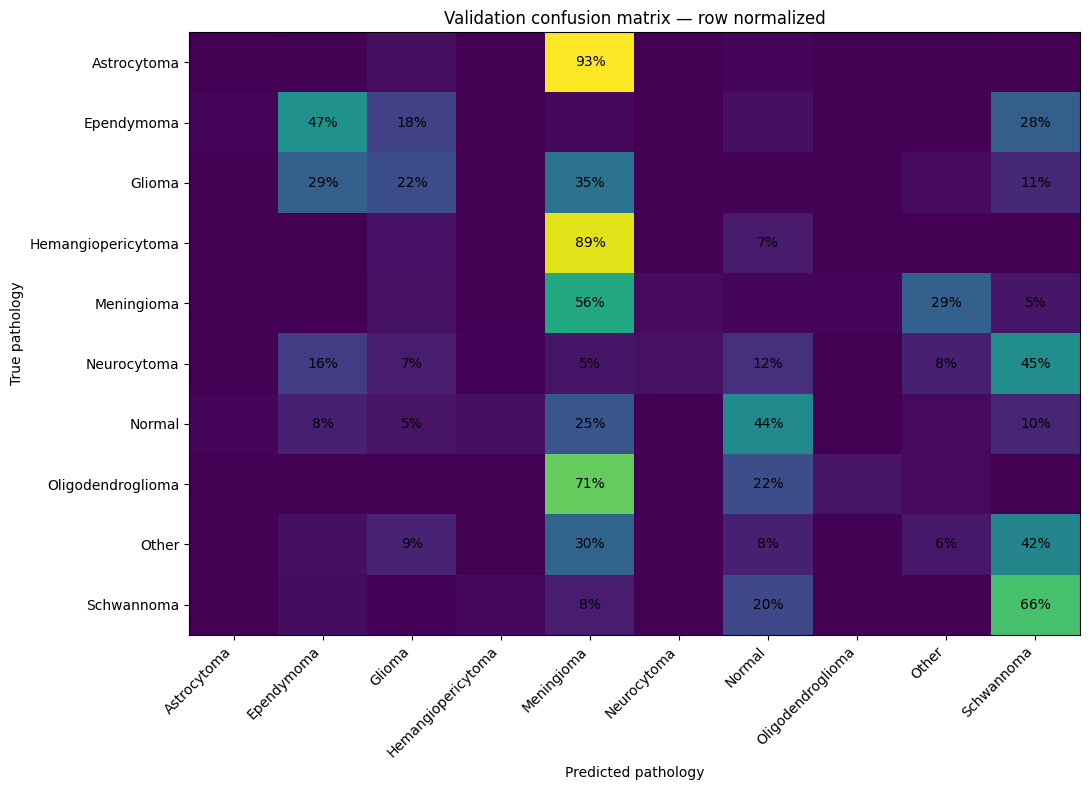

In [84]:
# ============================================================
# FINAL CONFUSION MATRIX
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd

class_names = [
    idx_to_class[i]
    for i in sorted(idx_to_class)
]

confusion = pd.crosstab(
    results_df["pathology"],
    results_df["y_pred"].map(idx_to_class),
    normalize="index"
)

confusion = confusion.reindex(
    index=class_names,
    columns=class_names,
    fill_value=0
)

fig, ax = plt.subplots(figsize=(11, 8))

im = ax.imshow(
    confusion.values,
    aspect="auto"
)

ax.set_xticks(range(len(class_names)))
ax.set_xticklabels(
    class_names,
    rotation=45,
    ha="right"
)

ax.set_yticks(range(len(class_names)))
ax.set_yticklabels(class_names)

ax.set_xlabel("Predicted pathology")
ax.set_ylabel("True pathology")
ax.set_title(
    "Validation confusion matrix — row normalized"
)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        value = confusion.iloc[i, j]

        if value >= 0.05:
            ax.text(
                j,
                i,
                f"{100 * value:.0f}%",
                ha="center",
                va="center"
            )

plt.tight_layout()
plt.show()

## Final diagnosis

The baseline model shows poor generalization to held-out groups, with an
image-level validation accuracy of approximately 30%. Performance is strongly
heterogeneous across validation groups: 24 of 55 groups have 0% accuracy,
while other groups from the same pathology achieve substantially higher
performance, including near-perfect accuracy in some cases.

Several potential explanations for this behavior were investigated.

### Framing shift

The proportion of black pixels varies substantially between training and
validation for several pathologies, indicating differences in image framing.
However, framing distance does not explain validation performance globally.
Some pathology-specific associations were observed, particularly for
Meningioma and Glioma, suggesting that framing contributes to the problem
locally but is not sufficient to explain the overall generalization failure.

### Anatomical location

Anatomical location distributions also differ between groups. However,
validation performance is not globally associated with the frequency of a
location configuration in the training set. Some unseen location
configurations generalize well, while some heavily represented configurations
perform poorly.

Therefore, lack of anatomical coverage alone does not explain the observed
failure.

### Group-level prediction behavior

The strongest pattern is observed at the group level.

Among validation groups with accuracy <= 25%, the median share assigned to
their dominant predicted class is approximately 72%. Half of these poorly
performing groups have at least 75% of their images assigned to a single
predicted class, and several groups are almost entirely mapped to the same
incorrect class.

For example, entire Astrocytoma and Glioma groups are systematically predicted
as Meningioma, while other groups are systematically mapped to Ependymoma,
Schwannoma, or Normal.

This indicates that the validation failure is structured rather than random:
images belonging to the same held-out group frequently fail in a consistent
way.

### Conclusion

The experiments do not support a single measured covariate as the explanation
for the poor validation performance.

Instead, the results are consistent with a multifactorial group-level
distribution shift. Differences in framing, acquisition characteristics,
anatomical presentation, image appearance, or other unobserved source-related
factors may jointly contribute to the model's behavior.

The current model should therefore be treated as a baseline with limited
generalization to unseen groups.

The next stage of the project will evaluate mitigation strategies using the
same group-based validation protocol and compare them against this baseline.